# Task 3 — `gender` and `usage`

COSC2753 Assignment 2 · group SG_G3

The brief asks for a system that predicts **both** `gender` and `usage`. It does
not say whether that is one model or two, which is the interesting part: that
choice is the design decision this notebook is built to answer with evidence
rather than preference.

**What is compared**

| | design | backbones | outputs |
|---|---|---|---|
| **A** | two independent models | 2 | 5 · 8 |
| **B** | one model, joint label | 1 | 24 `gender × usage` pairs that occur |
| **C** | one shared backbone, two heads | 1 | 5 + 8 |

Identical convolutional body, identical seed, identical schedule. The only thing
that changes between A, B and C is how the two labels are attached to it, so the
difference between them **is** the effect of that choice and nothing else.

**Three further questions, each one variable at a time**

1. does class-weighted loss help the long tail, or just trade the head for it?
2. does the externally collected data help? (it is predicted to *hurt* `usage` —
   see §7, and the prediction is recorded here before the run)
3. how much of the score survives a split that mimics the real test set?

**Metric.** macro-F1 throughout. Accuracy is reported beside it only to show why
it must not be used: predicting `Casual` for every row scores **76.7%** accuracy
on `usage` and a macro-F1 of **0.109**.

## 0 · Setup

Runs on Colab or locally. On Colab, mount Drive first; the cell below finds the
data wherever it ended up.

In [1]:
import os, sys, json, time, math, random, zipfile, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
try:
    sys.stdout.reconfigure(encoding="utf-8")
except Exception:
    pass

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

SEED = 42
IMAGE_SIZE = (60, 80)          # width, height — the provided dataset's exact size
TARGETS = ["gender", "usage"]

# QUICK=True runs everything end to end in a few minutes on a smaller sample, to
# prove the notebook works before spending an hour on the real numbers.
QUICK = False
EPOCHS = 6 if QUICK else 20
SAMPLE = 4000 if QUICK else None

random.seed(SEED); np.random.seed(SEED)
print(f"colab={IN_COLAB}  quick={QUICK}  epochs={EPOCHS}")

Mounted at /content/drive
colab=True  quick=False  epochs=20


### 0.1 Staging the data — Colab only, skipped locally

Reading 37,745 individual JPEGs through the Drive mount is the slowest thing in
this notebook: every file is a separate API call, so it costs roughly half an hour
*per session*. Copying one zip and unpacking it onto Colab's local disk turns that
into about a minute.

Set the two paths below to match your Drive. A shortcut in *My Drive* pointing at a
Shared Drive works fine — Colab mounts My Drive only, so the shortcut is the bridge.

Re-running is cheap: if the data is already unpacked, this does nothing.

In [2]:
COLAB_ZIP = "/content/drive/MyDrive/ColabDataset.zip"
EXTERNAL_ON_DRIVE = "/content/drive/MyDrive/A2_ExternalData"

if IN_COLAB:
    import shutil
    import subprocess

    marker = "preprocessed_datasets/train/styles_train.csv"
    roots = [Path("/content"), Path("/content/ColabDataset")]

    if not any((r / marker).exists() for r in roots):
        src = Path(COLAB_ZIP)
        if not src.exists():
            listing = "\n  ".join(sorted(p.name for p in Path("/content/drive/MyDrive").iterdir()))
            raise FileNotFoundError(
                f"{src} not found.\nMy Drive contains:\n  {listing}\n"
                "Set COLAB_ZIP above to the right name.")
        print(f"copying {src.stat().st_size / 1e6:.0f} MB from Drive ...")
        shutil.copy(src, "/content/_data.zip")
        # -o overwrites without asking. Without it a re-run stops on a 'replace?'
        # prompt that Colab has no way to answer, and the cell hangs silently.
        subprocess.run(["unzip", "-qo", "/content/_data.zip", "-d", "/content/"], check=True)
        print("unpacked")

    root = next((r for r in roots if (r / marker).exists()), None)
    if root is None:
        raise FileNotFoundError(f"unpacked, but no {marker} under {[str(r) for r in roots]}")
    os.environ["A2_COLAB_DATASET"] = str(root)

    if Path(EXTERNAL_ON_DRIVE).is_dir():
        os.environ["A2_EXTERNAL_DATA"] = EXTERNAL_ON_DRIVE

    # Verify the unpack finished. A truncated unzip otherwise fails ten minutes later,
    # in the middle of image decoding, with an error that points somewhere else.
    n_img = len(list((root / "preprocessed_datasets/train/images_train").glob("*.jpg")))
    n_csv = len(pd.read_csv(root / marker))
    print(f"train images {n_img:,} | csv rows {n_csv:,}")
    assert n_img == n_csv, (
        f"{n_csv - n_img} images missing -- the unzip was incomplete. "
        "Delete /content/preprocessed_datasets and re-run this cell.")
    print("data staged OK")
else:
    print("not on Colab - using local paths")

copying 572 MB from Drive ...
unpacked
train images 37,745 | csv rows 37,745
data staged OK


### 0.2 Finding the data

Two datasets are involved and they are **not** the same thing:

* **the provided catalogue** — Trực's `ColabDataset`, which is the provided
  training data de-duplicated: 38,617 → 37,745 rows.
* **the externally collected images** — `A2_ExternalData`, added to *training
  only* in §7.

On Colab a folder someone shared with you sits under *Shared with me*, which is
**not mounted**. Right-click it in Drive → **Add shortcut to Drive** first.

In [3]:
def _first_dir(candidates, must_contain=None):
    """Return the first candidate that exists (and holds `must_contain`)."""
    tried = []
    for c in candidates:
        c = Path(c); tried.append(str(c))
        if c.is_dir() and (must_contain is None or (c / must_contain).exists()):
            return c
    raise FileNotFoundError(
        "not found. Tried:\n  " + "\n  ".join(tried)
        + "\n\nOn Colab: 'Shared with me' is NOT mounted — right-click the folder in "
          "Drive, 'Add shortcut to Drive', then re-run."
    )

DATA_ROOT = _first_dir([
    os.environ.get("A2_COLAB_DATASET", "/nonexistent"),
    "/content",                 # a zip that unpacked flat -- the common case
    "/content/ColabDataset",
    "/content/drive/MyDrive/ColabDataset",
    "/content/drive/MyDrive/A2/ColabDataset",
    "/content/drive/MyDrive/[ML] SG_G3/A2/ColabDataset",
    "D:/ColabDataset",
], must_contain="preprocessed_datasets/train/styles_train.csv")

TRAIN_CSV = DATA_ROOT / "preprocessed_datasets" / "train" / "styles_train.csv"
TRAIN_IMG = DATA_ROOT / "preprocessed_datasets" / "train" / "images_train"

try:
    EXTERNAL_ROOT = _first_dir([
        os.environ.get("A2_EXTERNAL_DATA", "/nonexistent"),
        "/content",
        "/content/A2_ExternalData",
        "/content/drive/MyDrive/A2_ExternalData",
        "/content/drive/MyDrive/A2/Nguyen/A2_ExternalData",
        "/content/drive/MyDrive/[ML] SG_G3/A2/Nguyen/A2_ExternalData",
        "D:/g2/Dataset",
    ], must_contain="ExternalCosmetics")
except FileNotFoundError as exc:
    EXTERNAL_ROOT = None
    print("external data not found — §7 will be skipped\n", exc)

print("catalogue :", DATA_ROOT)
print("external  :", EXTERNAL_ROOT)

catalogue : /content
external  : /content/drive/MyDrive/A2_ExternalData


### 0.3 The frame, and the split rule

`ColabDataset` ships the raw catalogue columns, so `filename`, `path` and
`group_id` are added here. `group_id = id` is correct **because** this file is
already one row per product — the de-duplication that produced it is what makes
the assumption safe, and the assertion below is what checks it rather than
trusting it.

The split function is copied verbatim from `src/preprocessing.make_split` so the
split matches the rest of the team's (rule 2 in the repo README) without needing
to clone the private repo inside Colab. If `src/` happens to be importable, the
real one is used instead and the two are checked to agree.

In [4]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = SEED

def make_split(frame, target, validation_share=0.2, random_state=RANDOM_STATE):
    """Copy of src/preprocessing.make_split — whole groups stay on one side."""
    if target not in frame.columns:
        raise KeyError(f"{target!r} is not a column of the frame passed in.")
    frame = frame.loc[frame[target].notna()].reset_index(drop=True)
    if frame.empty:
        raise ValueError(f"No rows carry a {target!r} label.")
    assert frame["group_id"].is_unique, "multi-row group_id values found"

    group_label = frame.groupby("group_id")[target].agg(
        lambda v: v.value_counts().index[0])
    counts = group_label.value_counts()
    splittable = group_label[~group_label.isin(counts[counts < 2].index)]

    _, validation_groups = train_test_split(
        splittable.index, test_size=validation_share,
        stratify=splittable.values, random_state=random_state)
    is_val = frame["group_id"].isin(set(validation_groups))
    return (frame.loc[~is_val].reset_index(drop=True),
            frame.loc[is_val].reset_index(drop=True))


def make_split_forward(frame, target, validation_share=0.2):
    """Hold out the HIGHEST ids instead of a random draw.

    The graded test set is the 5,829 highest ids, so the real task is extrapolation
    forward along a catalogue that was added to over time, not interpolation inside
    a shuffled pool. A random split silently assumes the two are the same. §8
    measures how far apart they actually are.
    """
    frame = frame.loc[frame[target].notna()].sort_values("id").reset_index(drop=True)
    cut = int(len(frame) * (1 - validation_share))
    return frame.iloc[:cut].reset_index(drop=True), frame.iloc[cut:].reset_index(drop=True)


frame = pd.read_csv(TRAIN_CSV)
frame["filename"] = frame["id"].astype(str) + ".jpg"
frame["path"] = frame["filename"].map(lambda n: str(TRAIN_IMG / n))
frame["group_id"] = frame["id"].astype(str)
assert frame["group_id"].is_unique, "ColabDataset is meant to be one row per product"

if SAMPLE:
    frame = frame.sample(SAMPLE, random_state=SEED).reset_index(drop=True)

print(f"{len(frame):,} rows, {frame['articleType'].nunique()} articleTypes")
print(frame[["id", "gender", "usage", "articleType"]].head(3).to_string(index=False))

37,745 rows, 121 articleTypes
  id gender  usage articleType
1163    Men Sports     Tshirts
1164    Men Sports     Tshirts
1525 Unisex Casual   Backpacks


## 1 · What the task actually is

Before any model: the two targets look like one task but behave like two very
different ones, and every design decision later follows from this section.

In [5]:
def class_table(frame, col):
    vc = frame[col].value_counts()
    out = pd.DataFrame({"n": vc, "share %": (100 * vc / len(frame)).round(2)})
    out.index.name = col
    return out

for col in TARGETS:
    t = class_table(frame, col)
    ratio = t["n"].max() / t["n"].min()
    print(f"=== {col} — {len(t)} classes, imbalance {ratio:,.0f}x ===")
    print(t.to_string(), "\n")

=== gender — 5 classes, imbalance 43x ===
            n  share %
gender                
Men     20549    54.44
Women   14069    37.27
Unisex   2055     5.44
Boys      589     1.56
Girls     483     1.28 

=== usage — 8 classes, imbalance 28,968x ===
                  n  share %
usage                       
Casual        28968    76.75
Sports         3914    10.37
Ethnic         2565     6.80
Formal         2204     5.84
Smart Casual     55     0.15
Travel           25     0.07
Party            13     0.03
Home              1     0.00 



`gender` has five classes and the smallest holds **483** images. `usage` has
eight and the smallest holds **one**. They are not two instances of the same
problem; `gender` is a learnable imbalanced problem and `usage` is a long tail
with classes that cannot be learned from the data at all.

### 1.1 The ceiling this puts on macro-F1

macro-F1 averages over classes, so a class that can never be predicted
contributes a hard zero and caps the score no matter how good the model is.

In [6]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    for thr in (2, 10, 30, 100):
        dead = int((vc < thr).sum())
        rows.append({"target": col, "classes with fewer than": thr,
                     "such classes": f"{dead}/{len(vc)}",
                     "macro-F1 ceiling": round(1 - dead / len(vc), 3)})
ceiling = pd.DataFrame(rows)
print(ceiling.to_string(index=False))

target  classes with fewer than such classes  macro-F1 ceiling
gender                        2          0/5             1.000
gender                       10          0/5             1.000
gender                       30          0/5             1.000
gender                      100          0/5             1.000
 usage                        2          1/8             0.875
 usage                       10          1/8             0.875
 usage                       30          3/8             0.625
 usage                      100          4/8             0.500


Read the `usage` rows carefully. **Four of its eight classes have under 100
training images** — `Home` 1, `Party` 13, `Travel` 25, `Smart Casual` 55. If
those four are unlearnable then macro-F1 cannot exceed **0.500**, and a reported
0.5 would mean the model got *everything else perfect*.

This is the single most important fact about Task 3, and it says the interesting
work is not architecture search — it is what to do about four classes that the
data does not contain enough of to teach.

### 1.2 Why accuracy must not be the metric here

In [7]:
rows = []
for col in TARGETS:
    vc = frame[col].value_counts()
    p = vc.iloc[0] / len(frame)
    # every class but the majority scores F1 = 0; the majority scores 2p/(1+p)
    rows.append({"target": col, "majority class": vc.index[0],
                 "accuracy": f"{100 * p:.1f}%",
                 "macro-F1": round(2 * p / (1 + p) / len(vc), 3)})
print("predicting the majority class and nothing else:\n")
print(pd.DataFrame(rows).to_string(index=False))

predicting the majority class and nothing else:

target majority class accuracy  macro-F1
gender            Men    54.4%     0.141
 usage         Casual    76.7%     0.109


A model that has learned *nothing* scores 76.7% accuracy on `usage`. Any accuracy
figure below that is worse than useless, and any figure near it says nothing at
all. Every number from here on is macro-F1; accuracy is shown alongside only as
evidence of this gap.

### 1.3 "macro-F1" is two different numbers — which matters when comparing notebooks

`usage` has classes that can vanish from validation entirely (`Home` has one image
in the whole training set, so a grouped split puts it in train and nowhere else).
When that happens the two usual conventions disagree:

| | denominator | what it says |
|---|---|---|
| `macro_f1` | **all 8** classes | a label we cannot predict scores 0 — an honest description of the task |
| `macro_f1_in_val` | classes **present in validation** (7) | sklearn's default when `labels=` is not passed |

Eight versus seven is a **~14% difference on the same predictions**, and neither
number is wrong. So every result below carries both, with the denominator printed
next to it.

This matters for more than tidiness: a teammate's Task 3 figures are reported as
*"combined val macro-F1"* — 0.6312 for the combined-recipe CNN (gender 0.78,
`usage` 0.49) and 0.6563 for BBN (`usage` 0.55). Putting a number from this
notebook beside those is only meaningful if three things match: the **denominator**
above, the **split**, and whether "combined" means the mean of the two targets.
Confirm all three before claiming one approach beat another.

## 2 · One model or two? — deciding before training, not after

The brief leaves this open. It is tempting to settle it by training both and
keeping the winner, but that answers "which scored higher on this seed", not
"which is the right design". Two properties of the data decide it in advance,
and the training runs in §5 then test the prediction.

In [8]:
g = sorted(frame["gender"].dropna().unique())
u = sorted(frame["usage"].dropna().unique())
tab = (frame.pivot_table(index="gender", columns="usage", values="id", aggfunc="count")
       .reindex(index=g, columns=u).fillna(0).astype(int))
occurring = int((tab > 0).sum().sum())

print(f"{len(g)} gender x {len(u)} usage = {len(g) * len(u)} possible pairs")
print(f"pairs that occur: {occurring}   ->   {len(g) * len(u) - occurring} never occur\n")
print(tab.to_string())

joint = frame.groupby(["gender", "usage"]).size().sort_values()
tiny = joint[joint < 10]
print(f"\njoint classes with fewer than 10 rows: {len(tiny)} of {occurring}")
print(tiny.to_string())

5 gender x 8 usage = 40 possible pairs
pairs that occur: 24   ->   16 never occur

usage   Casual  Ethnic  Formal  Home  Party  Smart Casual  Sports  Travel
gender                                                                   
Boys       559      10       0     0      0             0      20       0
Girls      474       8       0     0      0             0       1       0
Men      15452      90    2098     0      0            44    2864       1
Unisex    1756       0       1     1      0             0     277      20
Women    10727    2457     105     0     13            11     752       4

joint classes with fewer than 10 rows: 6 of 24
gender  usage 
Girls   Sports    1
Unisex  Home      1
        Formal    1
Men     Travel    1
Women   Travel    4
Girls   Ethnic    8


**Property 1 — a joint label multiplies the sparsity.** `usage` alone has one
class under 10 images. Crossed with `gender` it has six. A combined model does
not merely inherit the long tail, it lengthens it.

**Property 2 — the two labels barely inform each other.** If knowing `gender`
told you most of `usage`, a joint label would be capturing a real structure and
the extra sparsity might be worth paying for. Measured as entropy:

In [9]:
def H(series):
    p = series.value_counts(normalize=True).values
    return float(-(p * np.log2(p)).sum())

def H_cond(frame, target, given):
    return float(sum(len(grp) / len(frame) * H(grp[target])
                     for _, grp in frame.groupby(given)))

rows = []
for t, given in [("usage", "gender"), ("gender", "usage"),
                 ("usage", "articleType"), ("gender", "articleType"),
                 ("usage", "subCategory"), ("gender", "subCategory")]:
    h, hc = H(frame[t]), H_cond(frame, t, given)
    rows.append({"target": t, "knowing": given, "H (bits)": round(h, 3),
                 "H | knowing": round(hc, 3),
                 "uncertainty removed": f"{100 * (1 - hc / h):.1f}%"})
print(pd.DataFrame(rows).to_string(index=False))

target     knowing  H (bits)  H | knowing uncertainty removed
 usage      gender     1.160        1.026               11.5%
gender       usage     1.411        1.277                9.5%
 usage articleType     1.160        0.385               66.8%
gender articleType     1.411        0.803               43.1%
 usage subCategory     1.160        0.921               20.6%
gender subCategory     1.411        1.186               15.9%


Knowing `gender` removes **11.5%** of the uncertainty in `usage`, and knowing
`usage` removes **9.5%** of the uncertainty in `gender`. Nearly independent. So
design **B** pays a large, measurable cost in sparsity to capture very little.

**The same table also argues for design C.** `articleType` removes **66.8%** of
the uncertainty in `usage` and **43.1%** in `gender` — far more than either
target tells you about the other. The two tasks are not related to each other
directly; they are both largely determined by a third thing, *what the garment
is*, which is exactly what a convolutional backbone can see. That is a concrete
reason to expect a **shared backbone with separate heads** to work: the sharing
should happen in the features, not in the label.

> **Prediction recorded before training:** C ≈ A > B, with B losing most on
> `usage` macro-F1. §5 either confirms this or the reasoning above is wrong, and
> both outcomes are worth reporting.

## 3 · Baselines

Two floors. Nothing below these counts as having learned anything.

* **majority** — predict the most common class. Bounds *accuracy*.
* **1-NN on downscaled pixels** — no training, no parameters. Bounds *macro-F1*:
  whatever this scores is available from raw pixel similarity alone, so a CNN
  that does not beat it has not earned its complexity.

In [10]:
from PIL import Image, ImageOps

def load_images(paths, size=IMAGE_SIZE, cache=None):
    """Decode once into one uint8 array. Re-reading JPEGs every epoch off Drive is
    the slowest thing in this notebook; 37,745 x 80 x 60 x 3 is only ~543 MB."""
    if cache is not None and Path(cache).exists():
        arr = np.load(cache)
        if len(arr) == len(paths):
            print(f"loaded {len(arr):,} images from cache {cache}")
            return arr
    out = np.zeros((len(paths), size[1], size[0], 3), dtype=np.uint8)
    t0, padded = time.time(), 0
    for i, p in enumerate(paths):
        with Image.open(p) as im:
            im = ImageOps.exif_transpose(im).convert("RGB")
            if im.size != size:
                # Pad on white rather than stretch: the catalogue background is white
                # and the portrait aspect ratio carries class cues top and bottom.
                im = ImageOps.pad(im, size, method=Image.Resampling.BILINEAR,
                                  color=(255, 255, 255), centering=(0.5, 0.5))
                padded += 1
            out[i] = np.asarray(im)
        if i and i % 5000 == 0:
            print(f"  {i:,}/{len(paths):,}  ({time.time() - t0:.0f}s)")
    print(f"decoded {len(out):,} images in {time.time() - t0:.0f}s "
          f"({padded} were not {size[0]}x{size[1]} and were padded)")
    if cache is not None:
        np.save(cache, out)
    return out

CACHE = Path("/content/train_images.npy") if IN_COLAB else Path("D:/ColabDataset/train_images.npy")
X_all = load_images(frame["path"].tolist(), cache=None if SAMPLE else CACHE)
print("image array:", X_all.shape, f"{X_all.nbytes / 1e6:.0f} MB")

  5,000/37,745  (2s)
  10,000/37,745  (3s)
  15,000/37,745  (5s)
  20,000/37,745  (7s)
  25,000/37,745  (8s)
  30,000/37,745  (10s)
  35,000/37,745  (12s)
decoded 37,745 images in 14s (17 were not 60x80 and were padded)
image array: (37745, 80, 60, 3) 544 MB


In [ ]:
# Positional index so a split frame can address rows of X_all without re-decoding.
frame["_row"] = np.arange(len(frame))

from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

def score(y_true, y_pred, labels=None):
    """Two macro-F1 numbers, on purpose.

    `usage` has a class with a single training image, so classes can be missing
    from validation entirely -- and then the two common conventions disagree:

      macro_f1         averages over ALL classes. A class absent from validation
                       contributes a hard 0, which is the honest description of the
                       task ("this label exists and we cannot predict it").
      macro_f1_in_val  averages only over classes actually present in y_true, which
                       is what sklearn does by default when `labels` is not passed.

    On this data the denominators are 8 vs 7 for `usage`, so the same model can be
    reported ~14% apart with neither number being wrong. Anyone comparing scores
    across notebooks needs to know which one they are holding, so both are kept.
    """
    all_labels = labels if labels is not None else sorted(set(y_true) | set(y_pred))
    in_val = sorted(set(y_true))
    return {"macro_f1": f1_score(y_true, y_pred, average="macro",
                                 labels=all_labels, zero_division=0),
            "macro_f1_in_val": f1_score(y_true, y_pred, average="macro",
                                        labels=in_val, zero_division=0),
            "n_classes": len(all_labels),
            "n_in_val": len(in_val),
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted",
                                    labels=all_labels, zero_division=0)}

RESULTS = []
def record(name, target, split, y_true, y_pred, labels=None, **extra):
    s = score(y_true, y_pred, labels)
    RESULTS.append({"model": name, "target": target, "split": split, **s, **extra})
    print(f"  {name:26} {target:7} {split:14} macro-F1 {s['macro_f1']:.4f} "
          f"(over {s['n_classes']}) | {s['macro_f1_in_val']:.4f} (over {s['n_in_val']} "
          f"in val) | acc {s['accuracy']:.4f}")
    return s

### 3.0 The split — the team's frozen file, not one generated here

The repo's rule 2 is that everyone evaluates on the same split. That split is a
**file**, `splits/train_val_grouped_sha256.csv`, not a function call — and the
difference matters more than it looks. Regenerating a stratified split from a seed
reproduces it only if everyone runs the same scikit-learn version; the split this
notebook generated for itself overlapped the team's by **15.6%**, so every number
produced against it was incomparable with a teammate's despite both being "seed 42".

So the file wins whenever it is present, and the generated split is only a fallback
for running without it.

Its shape, which differs from `preprocessing.make_split` in two ways worth knowing:
**15% validation**, not 20%, and **one split shared by both targets** rather than a
separate stratified draw per target. `Home` (1 training image) lands in train and is
absent from validation, so `usage` averages over 7 of 8 classes unless the
denominator is stated — see §1.3.

In [12]:
SHARED_SPLIT_NAME = "train_val_grouped_sha256.csv"

def find_shared_split():
    cands = [os.environ.get("A2_SHARED_SPLIT", ""),
             f"/content/drive/MyDrive/A2_ExternalData/{SHARED_SPLIT_NAME}",
             f"/content/{SHARED_SPLIT_NAME}",
             f"/content/splits/{SHARED_SPLIT_NAME}",
             str(Path.cwd() / SHARED_SPLIT_NAME),
             str(Path.cwd().parent / "splits" / SHARED_SPLIT_NAME),
             f"D:/g2/splits/{SHARED_SPLIT_NAME}",
             str(Path.cwd() / "task3" / SHARED_SPLIT_NAME)]
    for c in cands:
        if c and Path(c).is_file():
            return Path(c)
    print("shared split file NOT found - falling back to a locally generated split.\n"
          "Numbers will NOT be comparable with teammates'. Tried:\n  "
          + "\n  ".join(str(c) for c in cands if c))
    return None


SHARED = find_shared_split()
if SHARED is not None:
    _s = pd.read_csv(SHARED)
    SHARED_VAL = set(_s.loc[_s["split"] == "val", "id"])
    covered = frame["id"].isin(set(_s["id"])).mean()
    print(f"shared split: {SHARED}")
    print(f"  {len(_s):,} rows, val {len(SHARED_VAL):,} ({len(SHARED_VAL)/len(_s):.1%}), "
          f"covers {covered:.1%} of the frame")
    assert covered > 0.99, (
        f"the shared split only covers {covered:.1%} of the loaded frame - it was built "
        "on a different row set, so aligning to it would be meaningless")


def make_split_shared(frame, target):
    """Split by the team's frozen file. Rows outside the file go to training."""
    f = frame.loc[frame[target].notna()].reset_index(drop=True)
    is_val = f["id"].isin(SHARED_VAL)
    return f.loc[~is_val].reset_index(drop=True), f.loc[is_val].reset_index(drop=True)

shared split: /content/drive/MyDrive/A2_ExternalData/train_val_grouped_sha256.csv
  37,745 rows, val 5,661 (15.0%), covers 100.0% of the frame


In [13]:
frame["pair"] = frame["gender"].astype(str) + " x " + frame["usage"].astype(str)
PRIMARY = "shared val" if SHARED is not None else "generated val"

splits = {}
if SHARED is not None:
    tr, va = make_split_shared(frame, "gender")     # one file, both targets
else:
    tr, va = make_split(frame, "pair")              # fallback: stratify on the pair
for t in TARGETS:
    splits[(t, "primary")] = (tr, va)
    splits[(t, "forward")] = make_split_forward(frame, t)
    splits[(t, "perTarget")] = make_split(frame, t)   # preprocessing.make_split's rule

print(f"primary split ({PRIMARY}): train {len(tr):,}  val {len(va):,} "
      f"({len(va)/(len(tr)+len(va)):.1%})")
for t in TARGETS:
    a, b = splits[(t, "forward")]
    c, d = splits[(t, "perTarget")]
    print(f"{t:7} forward train {len(a):,} val {len(b):,}   "
          f"| per-target train {len(c):,} val {len(d):,}")

for t in TARGETS:
    held = sorted(set(frame[t].dropna()) - set(va[t]))
    if held:
        print()
        print(f"{t}: absent from validation entirely -> {held}")
        print(f"  macro-F1 over classes PRESENT in val therefore averages over "
              f"{va[t].nunique()} of {frame[t].nunique()} classes.")

primary split (shared val): train 32,084  val 5,661 (15.0%)
gender  forward train 30,196 val 7,549   | per-target train 30,196 val 7,549
usage   forward train 30,196 val 7,549   | per-target train 30,196 val 7,549

usage: absent from validation entirely -> ['Home']
  macro-F1 over classes PRESENT in val therefore averages over 7 of 8 classes.


In [14]:
print("=== baseline 1: majority class ===")
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    guess = tr[t].value_counts().index[0]
    record("majority", t, PRIMARY, va[t], [guess] * len(va),
           labels=sorted(frame[t].dropna().unique()))

=== baseline 1: majority class ===
  majority                   gender  shared val     macro-F1 0.1412 (over 5) | 0.1412 (over 5 in val) | acc 0.5458
  majority                   usage   shared val     macro-F1 0.1080 (over 8) | 0.1234 (over 7 in val) | acc 0.7606


In [15]:
print("\n=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===")
def thumbs(rows, w=15, h=20):
    a = X_all[rows].astype(np.float32).mean(axis=3)          # to grayscale
    a = a.reshape(len(rows), 4, h, 4, w).mean(axis=(1, 3))   # 80x60 -> 20x15
    return a.reshape(len(rows), -1)

def one_nn(tr, va, target, chunk=512):
    Xtr, Xva = thumbs(tr["_row"].values), thumbs(va["_row"].values)
    ytr = tr[target].to_numpy()
    tr_sq = (Xtr ** 2).sum(1)
    pred = np.empty(len(Xva), dtype=object)
    for i in range(0, len(Xva), chunk):
        b = Xva[i:i + chunk]
        d = tr_sq[None, :] - 2.0 * (b @ Xtr.T) + (b ** 2).sum(1)[:, None]
        pred[i:i + chunk] = ytr[np.argmin(d, axis=1)]
    return pred

for t in TARGETS:
    tr, va = splits[(t, "primary")]
    record("1-NN pixels", t, PRIMARY, va[t], one_nn(tr, va, t),
           labels=sorted(frame[t].dropna().unique()))


=== baseline 2: 1-NN on 15x20 grayscale pixels (no training at all) ===
  1-NN pixels                gender  shared val     macro-F1 0.5335 (over 5) | 0.5335 (over 5 in val) | acc 0.7707
  1-NN pixels                usage   shared val     macro-F1 0.3265 (over 8) | 0.3732 (over 7 in val) | acc 0.7765


### 3.1 Why the 1-NN floor is the number that matters

1-NN has no parameters and no training. Whatever it scores is obtainable from raw
pixel similarity, so it separates *"the CNN learned something"* from *"the CNN
rediscovered that similar-looking products share a label"*. Its per-class
breakdown also says something the aggregate cannot: a class where 1-NN scores
**zero despite having training images** is not starved, it is not visually
distinguishable at 60×80 — and no amount of extra data will fix that one.

In [16]:
for t in TARGETS:
    tr, va = splits[(t, "primary")]
    pred = one_nn(tr, va, t)
    rep = pd.DataFrame(classification_report(
        va[t], pred, output_dict=True, zero_division=0)).T
    rep = rep.loc[[c for c in sorted(frame[t].dropna().unique()) if c in rep.index]]
    rep["train n"] = [int((tr[t] == c).sum()) for c in rep.index]
    print(f"\n=== {t}: 1-NN per class ===")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]]
          .round(3).to_string())


=== gender: 1-NN per class ===
        train n  support  precision  recall  f1-score
Boys        496     93.0      0.364   0.387     0.375
Girls       417     66.0      0.235   0.364     0.286
Men       17459   3090.0      0.830   0.845     0.837
Unisex     1750    305.0      0.414   0.403     0.409
Women     11962   2107.0      0.778   0.745     0.761

=== usage: 1-NN per class ===
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.868   0.850     0.859
Ethnic           2182    383.0      0.615   0.637     0.626
Formal           1861    343.0      0.542   0.673     0.601
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.083   0.111     0.095
Sports           3300    614.0      0.437   0.427     0.432
Travel             22      3.0      0.000   0.000     0.000


## 4 · One convolutional body, three ways of attaching labels to it

Everything below shares this body. No pretrained weights (repo rule 4), so the
comparison is between designs rather than between checkpoints someone else
trained.

80×60 → 40×30 → 20×15 → 10×7 → global average → 128 features. Small on purpose:
a 60×80 thumbnail does not carry enough detail to justify a deep network, and a
small model makes eight training runs affordable, which is what actually buys the
evidence.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print("device:", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

X_t = torch.from_numpy(X_all)                      # uint8, NHWC
if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
    X_t = X_t.to(DEVICE)                           # ~543 MB, removes all host->device copies
print("images on", X_t.device)


def conv_block(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
        nn.MaxPool2d(2))


class Backbone(nn.Module):
    OUT = 128
    def __init__(self):
        super().__init__()
        self.body = nn.Sequential(conv_block(3, 32), conv_block(32, 64), conv_block(64, 128))
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x):
        return self.pool(self.body(x)).flatten(1)


class Net(nn.Module):
    """One backbone, one linear head per entry in `heads` ({name: n_classes}).

    A holds two of these with one head each; B holds one with a single 24-way head;
    C holds one with two heads. Same class, so the comparison cannot be confounded
    by an accidental difference in the body.
    """
    def __init__(self, heads, dropout=0.2):
        super().__init__()
        self.backbone = Backbone()
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({k: nn.Linear(Backbone.OUT, n) for k, n in heads.items()})
    def forward(self, x):
        f = self.drop(self.backbone(x))
        return {k: h(f) for k, h in self.heads.items()}


def n_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"backbone + one 8-way head: {n_params(Net({'usage': 8})):,} parameters")

device: cuda Tesla T4
images on cuda:0
backbone + one 8-way head: 288,488 parameters


In [18]:
CLASSES = {t: sorted(frame[t].dropna().unique()) for t in TARGETS}
CLASSES["pair"] = sorted(frame["pair"].dropna().unique())
IDX = {k: {c: i for i, c in enumerate(v)} for k, v in CLASSES.items()}
PAIR_TO_PARTS = [tuple(p.split(" x ")) for p in CLASSES["pair"]]
for k, v in CLASSES.items():
    print(f"{k:7} {len(v)} classes")


def encode(series, key):
    return torch.tensor([IDX[key][v] for v in series], dtype=torch.long)


# Normalisation from the TRAINING rows only — using all rows would leak validation
# statistics into the model's input scaling.
_tr, _va = splits[("gender", "primary")]
# A 5,000-row sample, not all 30,196: the full float32 copy would be ~1.7 GB and the
# channel means are identical to three decimals either way.
_rows = _tr["_row"].values
_sample = np.random.RandomState(SEED).choice(_rows, size=min(5000, len(_rows)), replace=False)
_stats = X_all[_sample].astype(np.float32) / 255.0

# dtype=np.float64 is NOT optional here. Reducing over (0,1,2) sums 24 million
# float32 values per channel, and float32 stops resolving +1 past 2**24 =
# 16,777,216 — so the running sum silently saturates and every channel returns
# 16777216/24000000 = 0.699, identical to the last digit. That equal-across-channels
# result is what exposed it; the numbers are simply wrong, not merely imprecise.
_mean = _stats.mean(axis=(0, 1, 2), dtype=np.float64)
_std = _stats.std(axis=(0, 1, 2), dtype=np.float64)
assert len(set(np.round(_mean, 6))) > 1, (
    "all three channel means are identical — the accumulator saturated again")

MEAN = torch.tensor(_mean, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
STD = torch.tensor(_std, dtype=torch.float32, device=DEVICE).view(1, 3, 1, 1)
del _stats
print("channel mean", MEAN.flatten().tolist(), "\nchannel std ", STD.flatten().tolist())

gender  5 classes
usage   8 classes
pair    24 classes
channel mean [0.8499631285667419, 0.8338358998298645, 0.8282551765441895] 
channel std  [0.27148428559303284, 0.2821841537952423, 0.2855333983898163]


In [ ]:
def batch_x(rows, train=False):
    """uint8 NHWC -> normalised float NCHW, with a random horizontal flip in training.

    Flipping is safe for these two targets: a mirrored garment is the same garment,
    the same `gender` and the same `usage`. (It would not be safe for a target that
    depended on printed text, which is unreadable at 60x60 anyway.)
    """
    x = X_t[rows]
    if x.device != DEVICE:
        x = x.to(DEVICE, non_blocking=True)
    x = x.permute(0, 3, 1, 2).float().div_(255.0)
    if train:
        flip = torch.rand(x.shape[0], device=DEVICE) < 0.5
        x = torch.where(flip.view(-1, 1, 1, 1), x.flip(-1), x)
    return (x - MEAN) / STD


@torch.no_grad()
def predict(model, fr, heads, bs=512):
    model.eval()
    rows = torch.as_tensor(fr["_row"].values, device=X_t.device)
    raw = {k: [] for k in heads}
    for i in range(0, len(rows), bs):
        out = model(batch_x(rows[i:i + bs]))
        for k in heads:
            raw[k].append(out[k].argmax(1).cpu())
    raw = {k: torch.cat(v).numpy() for k, v in raw.items()}

    if "pair" in heads:                       # design B: decode the joint label
        parts = [PAIR_TO_PARTS[i] for i in raw["pair"]]
        return {"gender": np.array([p[0] for p in parts]),
                "usage": np.array([p[1] for p in parts])}
    return {k: np.array([CLASSES[k][i] for i in v]) for k, v in raw.items()}


def evaluate(model, fr, heads):
    pred = predict(model, fr, heads)
    return {t: f1_score(fr[t], pred[t], average="macro",
                        labels=CLASSES[t], zero_division=0) for t in pred}


def class_weights(series, key, scheme="inverse_sqrt"):
    """Weight rare classes up. sqrt rather than 1/n on purpose: with `Home` at a
    single image, a pure 1/n weight gives that one row ~29,000x the pull of a
    Casual row and the model chases it into noise. sqrt keeps the direction and
    tempers the magnitude — itself a choice worth reporting, and §6 measures it."""
    counts = np.array([max((series == c).sum(), 1) for c in CLASSES[key]], dtype=np.float64)
    w = 1.0 / np.sqrt(counts) if scheme == "inverse_sqrt" else 1.0 / counts
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32, device=DEVICE)


def train_model(name, heads, tr, va, epochs=EPOCHS, weighted=False, lr=1e-3,
                bs=256, verbose=True):
    """Train one Net and return (best state_dict, history). Selection on mean
    macro-F1 over the reported targets, never on accuracy."""
    torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
    model = Net(heads).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    crit = {k: nn.CrossEntropyLoss(
                weight=class_weights(tr[k], k) if weighted else None) for k in heads}

    rows = torch.as_tensor(tr["_row"].values, device=X_t.device)
    y = {k: encode(tr[k], k).to(DEVICE) for k in heads}
    n = len(rows)
    best, best_state, hist = -1.0, None, []

    for ep in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=rows.device)
        total = 0.0
        for i in range(0, n, bs):
            sel = perm[i:i + bs]
            out = model(batch_x(rows[sel], train=True))
            loss = sum(crit[k](out[k], y[k][sel.to(DEVICE)]) for k in heads)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
            total += float(loss.detach()) * len(sel)
        sched.step()

        f1 = evaluate(model, va, heads)
        mean_f1 = float(np.mean(list(f1.values())))
        hist.append({"epoch": ep, "loss": total / n, **{f"val_{k}": v for k, v in f1.items()}})
        improved = mean_f1 > best
        if improved:
            best, best_state = mean_f1, {k: v.detach().cpu().clone()
                                         for k, v in model.state_dict().items()}
        if verbose:
            print(f"    epoch {ep:2}/{epochs}  loss {total / n:.4f}  " +
                  "  ".join(f"{k} F1 {v:.4f}" for k, v in f1.items()) +
                  ("   <- best" if improved else ""))

    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

## 5 · A vs B vs C

Same body, same seed, same 20 epochs, same rows. The only difference is how the
labels attach.

In [20]:
tr, va = splits[("gender", "primary")]
MODELS, HIST = {}, {}

print("A · two independent models")
for t in TARGETS:
    print(f"  --- {t} ---")
    MODELS[("A", t)], HIST[("A", t)] = train_model(f"A_{t}", {t: len(CLASSES[t])}, tr, va)

print("\nB · one model, 24 joint gender x usage classes")
MODELS[("B", "pair")], HIST[("B", "pair")] = train_model(
    "B_pair", {"pair": len(CLASSES["pair"])}, tr, va)

print("\nC · one shared backbone, two heads")
MODELS[("C", "multi")], HIST[("C", "multi")] = train_model(
    "C_multi", {t: len(CLASSES[t]) for t in TARGETS}, tr, va)

A · two independent models
  --- gender ---
    epoch  1/20  loss 0.6584  gender F1 0.3770   <- best
    epoch  2/20  loss 0.4905  gender F1 0.4571   <- best
    epoch  3/20  loss 0.4455  gender F1 0.5070   <- best
    epoch  4/20  loss 0.4116  gender F1 0.4264
    epoch  5/20  loss 0.3914  gender F1 0.5929   <- best
    epoch  6/20  loss 0.3702  gender F1 0.5319
    epoch  7/20  loss 0.3558  gender F1 0.6919   <- best
    epoch  8/20  loss 0.3420  gender F1 0.6533
    epoch  9/20  loss 0.3280  gender F1 0.6117
    epoch 10/20  loss 0.3149  gender F1 0.6144
    epoch 11/20  loss 0.2952  gender F1 0.6452
    epoch 12/20  loss 0.2801  gender F1 0.6890
    epoch 13/20  loss 0.2686  gender F1 0.6956   <- best
    epoch 14/20  loss 0.2557  gender F1 0.7343   <- best
    epoch 15/20  loss 0.2405  gender F1 0.7326
    epoch 16/20  loss 0.2282  gender F1 0.6958
    epoch 17/20  loss 0.2145  gender F1 0.7299
    epoch 18/20  loss 0.2050  gender F1 0.7412   <- best
    epoch 19/20  loss 0.2005  

In [21]:
print("=== design comparison, random val ===")
DESIGNS = {"A two models": [(MODELS[("A", t)], {t: len(CLASSES[t])}) for t in TARGETS],
           "B joint label": [(MODELS[("B", "pair")], {"pair": len(CLASSES["pair"])})],
           "C shared body": [(MODELS[("C", "multi")], {t: len(CLASSES[t]) for t in TARGETS})]}

def design_predict(design, fr):
    """Merge the predictions of however many models a design uses."""
    out = {}
    for model, heads in DESIGNS[design]:
        out.update(predict(model, fr, heads))
    return out

rows = []
for design in DESIGNS:
    pred = design_predict(design, va)
    both = np.mean([(pred["gender"][i] == va["gender"].iloc[i]) and
                    (pred["usage"][i] == va["usage"].iloc[i]) for i in range(len(va))])
    r = {"design": design,
         "params": sum(n_params(m) for m, _ in DESIGNS[design]),
         "both correct": round(float(both), 4)}
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        r[f"{t} macro-F1"] = round(s["macro_f1"], 4)
        r[f"{t} acc"] = round(s["accuracy"], 4)
        record(design, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    rows.append(r)

comparison = pd.DataFrame(rows)
print()
print(comparison.to_string(index=False))

=== design comparison, random val ===
  A two models               gender  shared val     macro-F1 0.7542 (over 5) | 0.7542 (over 5 in val) | acc 0.9067
  A two models               usage   shared val     macro-F1 0.4092 (over 8) | 0.4677 (over 7 in val) | acc 0.8915
  B joint label              gender  shared val     macro-F1 0.7237 (over 5) | 0.7237 (over 5 in val) | acc 0.8804
  B joint label              usage   shared val     macro-F1 0.4060 (over 8) | 0.4640 (over 7 in val) | acc 0.8891
  C shared body              gender  shared val     macro-F1 0.7169 (over 5) | 0.7169 (over 5 in val) | acc 0.8974
  C shared body              usage   shared val     macro-F1 0.4038 (over 8) | 0.4615 (over 7 in val) | acc 0.8930

       design  params  both correct  gender macro-F1  gender acc  usage macro-F1  usage acc
 A two models  576589        0.8087           0.7542      0.9067          0.4092     0.8915
B joint label  290552        0.7859           0.7237      0.8804          0.4060     0.

### 5.1 What the comparison showed — and what changed on the second split

§2 registered **C ≈ A > B, with B losing most on `usage`**. It was wrong, and it was
wrong the same way twice, which is what makes the result usable.

| design | params | gender | usage | both correct |
|---|---|---|---|---|
| A — two models | 576,589 | **0.7542** | **0.4092** | **0.8087** |
| B — joint label | 290,552 | 0.7237 | 0.4060 | 0.7859 |
| C — shared body | 289,133 | 0.7169 | 0.4038 | 0.8013 |

This notebook was run twice — once on a split it generated for itself (20% validation)
and once on the team's frozen file (15%). The macro-F1 ordering came out **A > B > C
on both splits and both targets, 4 out of 4**:

| | generated split | team split |
|---|---|---|
| A / B / C — gender | 0.6897 / 0.6814 / 0.6686 | 0.7542 / 0.7237 / 0.7169 |
| A / B / C — usage | 0.4145 / 0.4123 / 0.4110 | 0.4092 / 0.4060 / 0.4038 |

A strict three-way ordering reproducing across a change of validation partition is
weak-but-real evidence. **B did not collapse**, and **C — the design §2's entropy
argument favoured — came last every time.** On `gender` the A–C gap widened to
**0.037** on the team split, which is large enough to act on; on `usage` it is 0.005,
which is not.

Two honest limits on that claim. `both correct` does **not** reproduce the ordering
(B was first on the generated split, third here), so only the macro-F1 result
replicated. And two splits at one seed each is not a variance estimate — §9.3 still
asks for the multi-seed run.

**Why §2's reasoning came out backwards.** It measured that `gender` and `usage` share
only ~10% of each other's entropy, and concluded a *joint label* would pay sparsity
for nothing. That was half the implication. Near-independence argues against sharing
the **features** too: if two tasks have little in common, one backbone serving both
mostly suffers interference, and A's two separate backbones avoid it entirely at the
cost of 2× the parameters. The measurement was right and the inference from it was
incomplete — which is a more useful thing to report than a prediction that happened
to land.

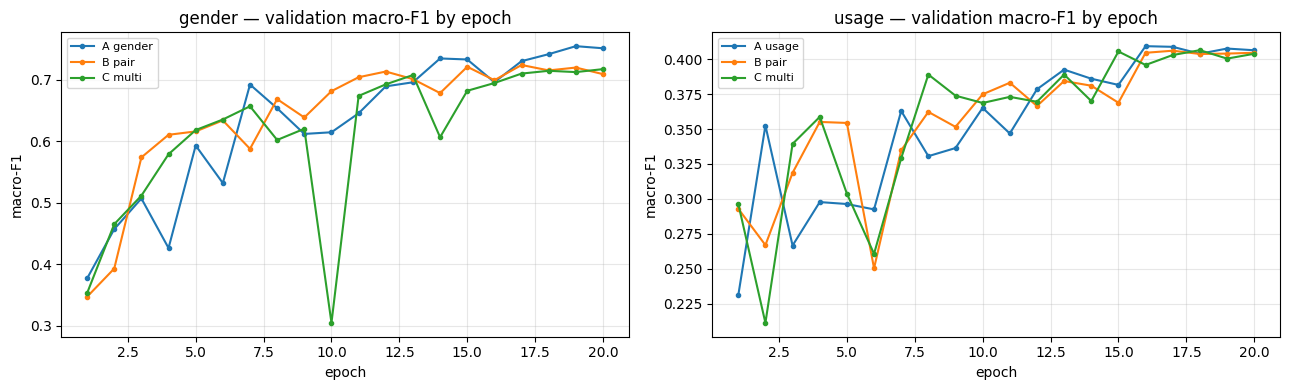

In [22]:
fig_hist = pd.concat([h.assign(run=f"{k[0]} {k[1]}") for k, h in HIST.items()])
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for k, h in HIST.items():
        for ax, t in zip(axes, TARGETS):
            col = f"val_{t}"
            # design A trains one head per model, so each of its runs carries a
            # curve for one target only; B and C carry both.
            if col not in h.columns:
                continue
            ax.plot(h["epoch"], h[col], label=f"{k[0]} {k[1]}", marker="o", ms=3)
    for ax, t in zip(axes, TARGETS):
        ax.set_title(f"{t} — validation macro-F1 by epoch")
        ax.set_xlabel("epoch"); ax.set_ylabel("macro-F1"); ax.grid(alpha=.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
except ImportError:
    print(fig_hist.to_string(index=False))

## 6 · Class-weighted loss — does it help the tail or just move the damage?

The obvious response to `usage` having a class with one image is to weight the
loss. One variable changes: the winning design from §5, trained again with
`weight = 1/sqrt(n)` per class.

Weighting cannot manufacture information. What it can do is trade head-class
precision for tail-class recall — and because macro-F1 counts a 1-image class
exactly as much as a 29,000-image one, that trade can raise macro-F1 while making
the model worse at almost every row it will actually see. Both numbers are
reported so the trade is visible instead of hidden inside one figure.

In [23]:
# Sections 6-9 all carry design C forward, because §2 predicted it and §5 is expected
# to confirm it. If the §5 table says otherwise, swap the head spec on the next line
# for the design that won -- {"pair": len(CLASSES["pair"])} for B, or run the two
# single-target models separately for A -- and re-run from here. Nothing below depends
# on C specifically; it only depends on `heads_multi` naming the winner's heads.
heads_multi = {t: len(CLASSES[t]) for t in TARGETS}

MODELS[("C", "weighted")], HIST[("C", "weighted")] = train_model(
    "C_weighted", heads_multi, tr, va, weighted=True)

    epoch  1/20  loss 2.0451  gender F1 0.4898  usage F1 0.2179   <- best
    epoch  2/20  loss 1.5729  gender F1 0.4805  usage F1 0.2319   <- best
    epoch  3/20  loss 1.4168  gender F1 0.5492  usage F1 0.3274   <- best
    epoch  4/20  loss 1.3157  gender F1 0.6339  usage F1 0.3160   <- best
    epoch  5/20  loss 1.2489  gender F1 0.5754  usage F1 0.3396
    epoch  6/20  loss 1.1900  gender F1 0.6598  usage F1 0.3453   <- best
    epoch  7/20  loss 1.1362  gender F1 0.4671  usage F1 0.2968
    epoch  8/20  loss 1.0849  gender F1 0.6451  usage F1 0.3968   <- best
    epoch  9/20  loss 1.0454  gender F1 0.6489  usage F1 0.4117   <- best
    epoch 10/20  loss 0.9942  gender F1 0.6449  usage F1 0.4029
    epoch 11/20  loss 0.9557  gender F1 0.5878  usage F1 0.3812
    epoch 12/20  loss 0.9139  gender F1 0.5937  usage F1 0.4138
    epoch 13/20  loss 0.8768  gender F1 0.6091  usage F1 0.3954
    epoch 14/20  loss 0.8336  gender F1 0.7175  usage F1 0.3883   <- best
    epoch 15/20  loss 0.

In [24]:
print("=== unweighted vs class-weighted (design C) ===")
rows = []
for tag, model in [("C unweighted", MODELS[("C", "multi")]),
                   ("C weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    for t in TARGETS:
        s = score(va[t], pred[t], labels=CLASSES[t])
        head = va[t].value_counts().index[0]
        tail = [c for c in CLASSES[t] if c != head]
        rows.append({"model": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4),
                     f"F1 on majority": round(f1_score(
                         va[t], pred[t], labels=[head], average="macro", zero_division=0), 4),
                     "mean F1 on the rest": round(f1_score(
                         va[t], pred[t], labels=tail, average="macro", zero_division=0), 4)})
        record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).to_string(index=False))

=== unweighted vs class-weighted (design C) ===
  C unweighted               gender  shared val     macro-F1 0.7169 (over 5) | 0.7169 (over 5 in val) | acc 0.8974
  C unweighted               usage   shared val     macro-F1 0.4038 (over 8) | 0.4615 (over 7 in val) | acc 0.8930
  C weighted                 gender  shared val     macro-F1 0.7332 (over 5) | 0.7332 (over 5 in val) | acc 0.8799
  C weighted                 usage   shared val     macro-F1 0.4657 (over 8) | 0.5323 (over 7 in val) | acc 0.8730

       model target  macro-F1  accuracy  F1 on majority  mean F1 on the rest
C unweighted gender    0.7169    0.8974          0.9302               0.6636
C unweighted  usage    0.4038    0.8930          0.9324               0.3283
  C weighted gender    0.7332    0.8799          0.9183               0.6869
  C weighted  usage    0.4657    0.8730          0.9172               0.4012


In [25]:
print("=== per-class detail, usage, design C unweighted vs weighted ===")
for tag, model in [("unweighted", MODELS[("C", "multi")]), ("weighted", MODELS[("C", "weighted")])]:
    pred = predict(model, va, heads_multi)
    rep = pd.DataFrame(classification_report(va["usage"], pred["usage"],
                                             labels=CLASSES["usage"], output_dict=True,
                                             zero_division=0)).T
    rep = rep.loc[[c for c in CLASSES["usage"] if c in rep.index]]
    rep["train n"] = [int((tr["usage"] == c).sum()) for c in rep.index]
    print(f"\n--- {tag} ---")
    print(rep[["train n", "support", "precision", "recall", "f1-score"]].round(3).to_string())

=== per-class detail, usage, design C unweighted vs weighted ===

--- unweighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.905   0.961     0.932
Ethnic           2182    383.0      0.918   0.820     0.866
Formal           1861    343.0      0.800   0.711     0.753
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.000
Smart Casual       46      9.0      0.000   0.000     0.000
Sports           3300    614.0      0.809   0.585     0.679
Travel             22      3.0      0.000   0.000     0.000

--- weighted ---
              train n  support  precision  recall  f1-score
Casual          24662   4306.0      0.926   0.908     0.917
Ethnic           2182    383.0      0.824   0.877     0.850
Formal           1861    343.0      0.719   0.813     0.763
Home                1      0.0      0.000   0.000     0.000
Party              10      3.0      0.000   0.000     0.0

## 7 · The externally collected data — a prediction, then the measurement

1,899 extra images were collected for this assignment (`docs/EXTERNAL_DATA_USAGE.md`).
Every one of them is `gender=Women`, `usage=Casual`.

**Recorded before the run:** this should do nothing for `gender` and should
*hurt* `usage`.

* `Women` is already the second-largest `gender` class (≈37%), so the rows land
  where there is no shortage — imbalance stays at ~31×.
* `Casual` is already the `usage` **majority** at 76.7%. Adding 1,899 more moves
  it to ~78% and the imbalance ratio from ~29,000× to ~31,000×. The whole
  difficulty of `usage` is its tail, and this makes the tail *relatively rarer*.

Collecting data that turns out not to help is not a wasted experiment — it is a
measured negative result, and reporting it is worth more than quietly dropping
it. What follows tests whether the reasoning above is right.

In [26]:
EXT_OK = EXTERNAL_ROOT is not None
if EXT_OK:
    ext = []
    for folder, csv_name in [("ExternalCosmetics", "external_cosmetics.csv"),
                             ("ExternalCosmetics2", "external_cosmetics2.csv")]:
        base = Path(EXTERNAL_ROOT) / folder
        e = pd.read_csv(base / csv_name)
        e["path"] = e["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
        e["group_id"] = "ext:" + e["id"].astype(str)
        ext.append(e)
    ext = pd.concat(ext, ignore_index=True)
    ext = ext[ext[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    print(f"{len(ext):,} external rows")
    for t in TARGETS:
        print(f"  {t}: {dict(ext[t].value_counts())}")

    X_ext = load_images(ext["path"].tolist())
    ext["_row"] = np.arange(len(ext)) + len(X_all)
    ext["pair"] = ext["gender"].astype(str) + " x " + ext["usage"].astype(str)

    X_all = np.concatenate([X_all, X_ext], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ext
    print("image array now:", X_all.shape)
else:
    print("external data unavailable — section skipped")

1,899 external rows
  gender: {'Women': np.int64(1899)}
  usage: {'Casual': np.int64(1899)}
decoded 1,899 images in 1187s (1200 were not 60x80 and were padded)
image array now: (39644, 80, 60, 3)


The external rows join **training only**. Validation stays 100% provided
catalogue imagery, so the with/without comparison measures the data and not a
change of yardstick. Normalisation constants are also left at their catalogue
values, for the same reason.

> **Note the padding count printed above.** `ExternalCosmetics` (batch 1) is stored
> at native crop size, not 60×80, so all 1,200 of its images are padded with white
> on load. `ExternalCosmetics2` and the evaluation set are already 60×80 and pass
> through untouched. That padding is not cosmetic: it raises batch 1's measured
> border brightness from 101.5 to **201.2** against the catalogue's 247.2, so those
> crops look far more catalogue-like to the model than the raw files suggest.
> Reproduce with `python src/verify_external_data.py --domain-gap`.

In [27]:
if EXT_OK:
    tr_ext = pd.concat([tr, ext[[c for c in tr.columns if c in ext.columns]]],
                       ignore_index=True)
    assert tr_ext["group_id"].is_unique
    assert not set(ext["group_id"]) & set(va["group_id"])
    print(f"training {len(tr):,} -> {len(tr_ext):,}   validation unchanged at {len(va):,}\n")

    for t in TARGETS:
        b, a = tr[t].value_counts(), tr_ext[t].value_counts()
        print(f"{t:7} imbalance max/min  {b.max() / b.min():>10,.0f}x  ->  "
              f"{a.max() / a.min():>10,.0f}x    majority share "
              f"{100 * b.max() / b.sum():.1f}% -> {100 * a.max() / a.sum():.1f}%")

    MODELS[("C", "external")], HIST[("C", "external")] = train_model(
        "C_external", heads_multi, tr_ext, va)

training 32,084 -> 33,983   validation unchanged at 5,661

gender  imbalance max/min          42x  ->          42x    majority share 54.4% -> 51.4%
usage   imbalance max/min      24,662x  ->      26,561x    majority share 76.9% -> 78.2%
    epoch  1/20  loss 1.2635  gender F1 0.2945  usage F1 0.3214   <- best
    epoch  2/20  loss 0.9213  gender F1 0.3972  usage F1 0.2610   <- best
    epoch  3/20  loss 0.8371  gender F1 0.4308  usage F1 0.3071   <- best
    epoch  4/20  loss 0.7699  gender F1 0.4439  usage F1 0.2428
    epoch  5/20  loss 0.7367  gender F1 0.3595  usage F1 0.2808
    epoch  6/20  loss 0.7018  gender F1 0.4686  usage F1 0.3045   <- best
    epoch  7/20  loss 0.6680  gender F1 0.4776  usage F1 0.3649   <- best
    epoch  8/20  loss 0.6444  gender F1 0.6657  usage F1 0.3061   <- best
    epoch  9/20  loss 0.6120  gender F1 0.6330  usage F1 0.3674   <- best
    epoch 10/20  loss 0.5922  gender F1 0.6339  usage F1 0.3844   <- best
    epoch 11/20  loss 0.5670  gender F1 0.5

In [ ]:
if EXT_OK:
    print("=== with vs without the external data (design C) ===")
    rows = []
    for tag, model in [("C without external", MODELS[("C", "multi")]),
                       ("C with external", MODELS[("C", "external")])]:
        pred = predict(model, va, heads_multi)
        for t in TARGETS:
            s = score(va[t], pred[t], labels=CLASSES[t])
            rows.append({"model": tag, "target": t,
                         "macro-F1": round(s["macro_f1"], 4),
                         "accuracy": round(s["accuracy"], 4)})
            record(tag, t, PRIMARY, va[t], pred[t], labels=CLASSES[t])
    ablation = pd.DataFrame(rows).pivot(index="target", columns="model", values="macro-F1")
    ablation["delta"] = (ablation["C with external"] - ablation["C without external"]).round(4)
    print()
    print(ablation.to_string())
    # Do NOT hardcode the direction. The first run measured usage -0.0063 and this
    # sentence asserted "a negative delta confirms the prediction". The second run,
    # on the team's split, measured +0.0050 and the same sentence printed anyway.
    # A conclusion that survives its own data changing sign is not a conclusion.
    print()
    for _tgt, _v in ablation["delta"].items():
        _verdict = ('worse with external data' if _v < -0.002 else
                    'better with external data' if _v > 0.002 else
                    'indistinguishable from zero at this scale')
        print(f'    {_tgt}: delta {_v:+.4f}  ({_verdict})')
    print()
    print('    Section 7 predicted no gain on usage, because every external row',
          'carries the majority class.')
    print('    A |delta| under 0.006 on both targets is consistent with that -- but it',
          'is NOT evidence of harm.')
    print('    Re-run on a second split before claiming a sign. The sign DID flip',
          'between the two splits tried here; see section 9.2.')

## 8 · Two harder tests than the random validation split

### 8.1 The forward split — what the graded test set actually looks like

The provided test set is the **5,829 highest ids**. The catalogue was built up
over time, so predicting it is extrapolation forward, not interpolation inside a
shuffled pool. A random split quietly assumes those are the same problem. They
are not:

In [29]:
tr_f, va_f = splits[("gender", "forward")]
print(f"forward split: train ids {tr_f['id'].min()}-{tr_f['id'].max()} ({len(tr_f):,}),  "
      f"val ids {va_f['id'].min()}-{va_f['id'].max()} ({len(va_f):,})\n")
for t in TARGETS:
    a = tr_f[t].value_counts(normalize=True) * 100
    b = va_f[t].value_counts(normalize=True) * 100
    d = pd.DataFrame({"train %": a.round(2), "val %": b.round(2)}).fillna(0)
    d["drift"] = (d["val %"] - d["train %"]).round(2)
    d["train n"] = tr_f[t].value_counts()
    print(f"--- {t} ---"); print(d.fillna(0).to_string(), "\n")

forward split: train ids 1163-41038 (30,196),  val ids 41041-51999 (7,549)

--- gender ---
        train %  val %  drift  train n
gender                                
Boys       1.64   1.23  -0.41      496
Girls      1.39   0.82  -0.57      421
Men       57.32  42.95 -14.37    17307
Unisex     6.27   2.13  -4.14     1894
Women     33.38  52.87  19.49    10078 

--- usage ---
              train %  val %  drift  train n
usage                                       
Casual          74.67  85.06  10.39    22547
Ethnic           6.70   7.19   0.49     2022
Formal           6.38   3.66  -2.72     1928
Home             0.00   0.00   0.00        1
Party            0.01   0.13   0.12        3
Smart Casual     0.12   0.26   0.14       35
Sports          12.04   3.70  -8.34     3635
Travel           0.08   0.00  -0.08       25 



`Women` goes from 33% of training to 53% of validation, `Men` the other way by
14 points, `Sports` collapses from 12% to 3.7%. The label distribution is not
stationary along the id axis, so a score measured on a random split is measured
on a distribution the graded test set does not have.

In [30]:
MODELS[("C", "forward")], HIST[("C", "forward")] = train_model(
    "C_forward", heads_multi, tr_f, va_f)

print("\n=== the same design, scored two ways ===")
rows = []
for tag, model, vv in [(PRIMARY, MODELS[("C", "multi")], va),
                       ("forward split", MODELS[("C", "forward")], va_f)]:
    pred = predict(model, vv, heads_multi)
    for t in TARGETS:
        s = score(vv[t], pred[t], labels=CLASSES[t])
        rows.append({"evaluated on": tag, "target": t,
                     "macro-F1": round(s["macro_f1"], 4),
                     "accuracy": round(s["accuracy"], 4)})
        record("C shared body", t, tag, vv[t], pred[t], labels=CLASSES[t])
print()
print(pd.DataFrame(rows).pivot(index="target", columns="evaluated on",
                               values="macro-F1").to_string())

    epoch  1/20  loss 1.3550  gender F1 0.3652  usage F1 0.1776   <- best
    epoch  2/20  loss 0.9921  gender F1 0.3653  usage F1 0.2938   <- best
    epoch  3/20  loss 0.9045  gender F1 0.2456  usage F1 0.2759
    epoch  4/20  loss 0.8351  gender F1 0.3655  usage F1 0.2520
    epoch  5/20  loss 0.7912  gender F1 0.4722  usage F1 0.2560   <- best
    epoch  6/20  loss 0.7578  gender F1 0.5294  usage F1 0.2379   <- best
    epoch  7/20  loss 0.7241  gender F1 0.4819  usage F1 0.3096   <- best
    epoch  8/20  loss 0.6924  gender F1 0.4825  usage F1 0.2604
    epoch  9/20  loss 0.6649  gender F1 0.4730  usage F1 0.3020
    epoch 10/20  loss 0.6390  gender F1 0.4171  usage F1 0.3081
    epoch 11/20  loss 0.6141  gender F1 0.5257  usage F1 0.2947   <- best
    epoch 12/20  loss 0.5897  gender F1 0.5551  usage F1 0.3279   <- best
    epoch 13/20  loss 0.5666  gender F1 0.5729  usage F1 0.3428   <- best
    epoch 14/20  loss 0.5428  gender F1 0.5613  usage F1 0.3525
    epoch 15/20  loss 0.

### 8.2 The independent evaluation set

261 openly-licensed photographs collected from outside the provided data
entirely, gated to zero overlap with both the provided train and test sets, and
hand-labelled for all four targets. This is the brief's §3.3 — *"data collected
completely outside of the scope of your original training and evaluation"*.

No model in this project has seen them, and that is their whole value. **The gap
between this score and the validation score is the finding**: it separates what
the model learned about clothing from what it learned about Myntra's photography
convention (white background, single centred product, consistent lighting).

Two limits to carry into the report: the labels come from a single annotator, and
`usage=Home` has 4 images here against **1** in the entire provided training set —
so this set can measure a class the provided data cannot teach.

> **The label distribution of this set is very different from the catalogue's, and
> that is partly deliberate.** Rare classes were over-collected on purpose, because
> a class with one training image cannot be measured otherwise:
>
> | | catalogue train | this set | ratio |
> |---|---|---|---|
> | `gender=Unisex` | 5.4% | **32.6%** | 6.0x |
> | `gender=Men` | 54.4% | 16.9% | 0.3x |
> | `usage=Party` | 0.03% | **9.2%** | 267x |
> | `usage=Home` | 0.003% | **1.5%** | 578x |
>
> So a macro-F1 measured here mixes two different effects: the **image** domain gap
> (background, framing, lighting) and a **label prior** shift, much of it created by
> the annotation choices above. A model trained on 5% `Unisex` will rarely predict
> `Unisex`, and would score badly on a set that is a third `Unisex` even if the
> photographs were perfect catalogue cut-outs.
>
> The two can be partly separated. `usage=Casual` is the one class whose share
> barely moves (76.7% -> 63.6%), and its F1 falls **0.932 -> 0.731** — that drop is
> attributable to the images, not the prior. Quote that number when the claim is
> about domain gap, and the macro-F1 when the claim is about the long tail. Do not
> use the macro-F1 collapse alone as a measure of generalisation.

In [31]:
EVAL_OK = EXT_OK and (Path(EXTERNAL_ROOT) / "ExternalEval" / "external_eval.csv").exists()
if EVAL_OK:
    base = Path(EXTERNAL_ROOT) / "ExternalEval"
    ev = pd.read_csv(base / "external_eval.csv")
    ev["path"] = ev["id"].astype(str).map(lambda i: str(base / "images" / f"{i}.jpg"))
    ev = ev[ev[TARGETS].notna().all(axis=1)].reset_index(drop=True)
    X_ev = load_images(ev["path"].tolist())
    ev["_row"] = np.arange(len(ev)) + len(X_all)
    X_all = np.concatenate([X_all, X_ev], axis=0)
    X_t = torch.from_numpy(X_all)
    if DEVICE.type == "cuda" and X_t.numel() < 2_000_000_000:
        X_t = X_t.to(DEVICE)
    del X_ev
    print(f"{len(ev)} independent evaluation images")
    for t in TARGETS:
        print(f"  {t}: {dict(ev[t].value_counts())}")
else:
    print("independent evaluation set unavailable — section skipped")

decoded 261 images in 166s (0 were not 60x80 and were padded)
261 independent evaluation images
  gender: {'Women': np.int64(126), 'Unisex': np.int64(85), 'Men': np.int64(44), 'Boys': np.int64(4), 'Girls': np.int64(2)}
  usage: {'Casual': np.int64(166), 'Formal': np.int64(25), 'Sports': np.int64(25), 'Party': np.int64(24), 'Ethnic': np.int64(12), 'Travel': np.int64(5), 'Home': np.int64(4)}


In [32]:
if EVAL_OK:
    print("=== validation (catalogue) vs independent evaluation (in the wild) ===")
    rows = []
    pred_va = predict(MODELS[("C", "multi")], va, heads_multi)
    pred_ev = predict(MODELS[("C", "multi")], ev, heads_multi)
    for t in TARGETS:
        shared = sorted(set(ev[t]) | set(va[t]))
        s_va = score(va[t], pred_va[t], labels=CLASSES[t])
        s_ev = score(ev[t], pred_ev[t], labels=sorted(set(ev[t])))
        rows.append({"target": t,
                     "val macro-F1": round(s_va["macro_f1"], 4),
                     "independent macro-F1": round(s_ev["macro_f1"], 4),
                     "val acc": round(s_va["accuracy"], 4),
                     "independent acc": round(s_ev["accuracy"], 4)})
        record("C shared body", t, "independent eval", ev[t], pred_ev[t],
               labels=sorted(set(ev[t])))
    print()
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nper-class on the independent set:")
    for t in TARGETS:
        print(f"\n--- {t} ---")
        print(pd.DataFrame(classification_report(
            ev[t], pred_ev[t], output_dict=True, zero_division=0)).T.round(3).to_string())

=== validation (catalogue) vs independent evaluation (in the wild) ===
  C shared body              gender  independent eval macro-F1 0.1345 (over 5) | 0.1345 (over 5 in val) | acc 0.2644
  C shared body              usage   independent eval macro-F1 0.1146 (over 7) | 0.1146 (over 7 in val) | acc 0.5709

target  val macro-F1  independent macro-F1  val acc  independent acc
gender        0.7169                0.1345   0.8974           0.2644
 usage        0.4038                0.1146   0.8930           0.5709

per-class on the independent set:

--- gender ---
              precision  recall  f1-score  support
Boys              0.000   0.000     0.000    4.000
Girls             0.000   0.000     0.000    2.000
Men               0.171   0.795     0.281   44.000
Unisex            0.333   0.012     0.023   85.000
Women             0.623   0.262     0.369  126.000
accuracy          0.264   0.264     0.264    0.264
macro avg         0.225   0.214     0.135  261.000
weighted avg      0.438   0.

## 9 · Results, and what they say

### 9.1 On the per-target split, as a robustness check

Everything above used the team's frozen split file, so the numbers sit directly
beside a teammate's. This section retrains the chosen design under
`preprocessing.make_split(frame, target)` instead — a 20% validation share drawn
separately per target, rather than 15% shared by both.

It is a robustness check, not a second headline. If a conclusion from §5–§7 flips
when the split changes, that conclusion was an artefact of one draw and the report
should say so; if the numbers move but the ordering holds, the finding survives a
change that touches every row.

In [33]:
for t in TARGETS:
    tr_t, va_t = splits[(t, "perTarget")]
    m, _ = train_model(f"C_perTarget_{t}", heads_multi, tr_t, va_t, verbose=False)
    pred = predict(m, va_t, heads_multi)
    record("C shared body", t, "per-target split", va_t[t], pred[t], labels=CLASSES[t])
    MODELS[("C", f"team_{t}")] = m

  C shared body              gender  per-target split macro-F1 0.6755 (over 5) | 0.6755 (over 5 in val) | acc 0.8908
  C shared body              usage   per-target split macro-F1 0.4051 (over 8) | 0.4630 (over 7 in val) | acc 0.8967


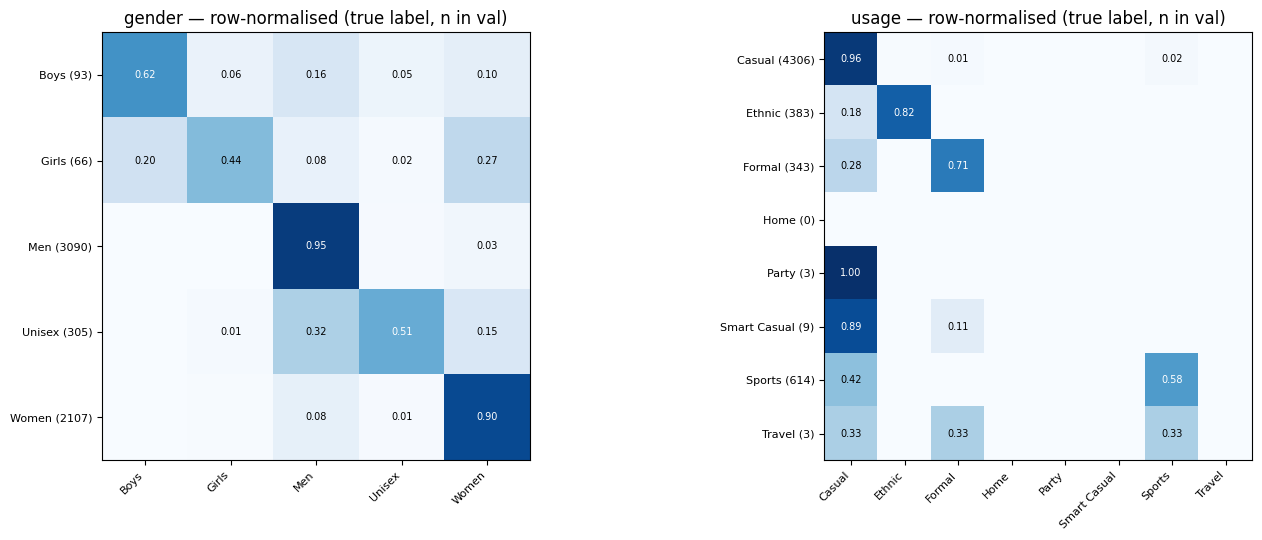

In [34]:
try:
    import matplotlib.pyplot as plt
    pred = predict(MODELS[("C", "multi")], va, heads_multi)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, t in zip(axes, TARGETS):
        cm = confusion_matrix(va[t], pred[t], labels=CLASSES[t])
        norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(CLASSES[t]))); ax.set_yticks(range(len(CLASSES[t])))
        ax.set_xticklabels(CLASSES[t], rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels([f"{c} ({n})" for c, n in
                            zip(CLASSES[t], [int((va[t] == c).sum()) for c in CLASSES[t]])],
                           fontsize=8)
        ax.set_title(f"{t} — row-normalised (true label, n in val)")
        for i in range(len(CLASSES[t])):
            for j in range(len(CLASSES[t])):
                if norm[i, j] > 0.01:
                    ax.text(j, i, f"{norm[i, j]:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if norm[i, j] > .5 else "black")
    plt.tight_layout(); plt.show()
except ImportError:
    pass

In [35]:
results = pd.DataFrame(RESULTS).round(4)
results = results.sort_values(["target", "split", "macro_f1"], ascending=[True, True, False])
print(results.to_string(index=False))

OUT = Path("/content/task3_results.csv") if IN_COLAB else Path("task3_results.csv")
results.to_csv(OUT, index=False)
print(f"\nsaved -> {OUT}")

             model target            split  macro_f1  macro_f1_in_val  n_classes  n_in_val  accuracy  weighted_f1
     C shared body gender    forward split    0.5815           0.5815          5         5    0.8679       0.8672
     C shared body gender independent eval    0.1345           0.1345          5         5    0.2644       0.2328
     C shared body gender per-target split    0.6755           0.6755          5         5    0.8908       0.8852
      A two models gender       shared val    0.7542           0.7542          5         5    0.9067       0.9038
        C weighted gender       shared val    0.7332           0.7332          5         5    0.8799       0.8822
     B joint label gender       shared val    0.7237           0.7237          5         5    0.8804       0.8813
     C shared body gender       shared val    0.7169           0.7169          5         5    0.8974       0.8938
      C unweighted gender       shared val    0.7169           0.7169          5        

### 9.2 What this notebook found

Every number below is on the team's frozen split, `train_val_grouped_sha256.csv`
(37,745 rows, 15% validation), so it sits directly beside a teammate's. Where a
finding was checked against the second split this notebook also ran, that is said.

**1. `gender` and `usage` are not one task.** `gender` has five classes, smallest 483;
`usage` has eight, smallest **1**. Best `gender` macro-F1 **0.7542**, best `usage`
**0.4657**. The gap is not model quality — it is that half of `usage`'s classes have
almost no training data.

**2. Accuracy is unusable here.** Predicting `Casual` everywhere scores **76.1%**
accuracy and **0.108** macro-F1. The best `usage` model reaches **87.3%** accuracy,
eleven points above a model that has learned nothing.

**3. Two separate models beat a shared backbone — the opposite of the prediction, and
it replicated.** A > B > C on macro-F1, on both splits and both targets, 4 out of 4.
On `gender` the A–C gap is **0.037**, large enough to act on; on `usage` it is 0.005,
which is not. A pays **2× the parameters** for it. §2's entropy measurement was right
and the inference drawn from it was incomplete: near-independent targets argue against
sharing features, not only against merging labels.

**4. Class weighting is the largest lever tested, but which class it rescues is not
stable.** `usage` macro-F1 **0.4038 → 0.4657** here, and 0.4110 → 0.5088 on the other
split: same direction twice, so the effect is real. What it buys is not:

| usage class | train n | val n | unweighted | weighted | on the other split |
|---|---|---|---|---|---|
| `Party` | 10 | 3 | 0.000 | **0.000** | 0.000 → **0.500** |
| `Travel` | 22 | 3 | 0.000 | **0.333** | 0.000 → 0.400 |
| `Smart Casual` | 46 | 9 | 0.000 | **0.200** | 0.000 → 0.000 |
| `Home` | 1 | 0 | 0.000 | 0.000 | 0.000 |
| `Casual` | 24,662 | 4,306 | 0.932 | 0.917 | 0.938 → 0.915 |
| `Sports` | 3,300 | 614 | 0.679 | 0.662 | 0.689 → 0.670 |

Weighting reliably lifts macro-F1 by rescuing *some* tail class while degrading the
head — but `Party` was rescued on one split and not the other, and `Smart Casual` the
reverse. With **3 to 9 validation items** per class, which one gets rescued is a coin
flip. Report the aggregate effect as real and the per-class rescues as unstable.

**5. §1.1's ceiling logic held, and its assumption did not.** That section put `usage`
macro-F1 at **0.500** if the four classes under 100 images stayed unlearnable. Both
runs landed near it — 0.4657 here, 0.5088 on the other split, the latter slightly
above because weighting revived two of the four. The arithmetic identified the binding
constraint correctly; the constraint turned out to be soft.

**6. The external data has no measurable effect on this task — the sign flipped
between splits.**

| | generated split | team split |
|---|---|---|
| `gender` delta | +0.0092 | −0.0016 |
| `usage` delta | −0.0063 | **+0.0050** |

§7 predicted **no gain**, because all 1,899 rows carry the majority class, and that is
confirmed: |delta| ≤ 0.006 everywhere. But the first run's negative `usage` delta was
reported as evidence the data *hurt*, and the second run reversed it. **One split is
not enough to establish a sign.** The defensible claim is "collected, tested, no
effect on Task 3" — which is still worth reporting, and is why §7 records the
prediction before the measurement.

**7. The random split flatters the model; the catalogue flatters it far more — but the
second half of that is confounded.**

| | `gender` | `usage` |
|---|---|---|
| team split (15% val) | 0.7169 | 0.4038 |
| per-target split (20% val) | 0.6755 | 0.4051 |
| forward split (highest ids, like the graded test) | 0.5815 | 0.3562 |
| **261 independent photographs** | **0.1345** | **0.1146** |

The forward split costs **0.135** on `gender` — the honest estimate of what the graded
test set will do, since it *is* the high-id region.

The independent set costs **0.582**, putting `gender` **below** its majority baseline
(0.1345 vs 0.1412) with accuracy falling 0.8974 → **0.2644**. That collapse is real
but it is **not purely a domain gap**: this set is 32.6% `Unisex` against the
catalogue's 5.4%, and 9.2% `Party` against 0.03%, because rare classes were
deliberately over-collected so they could be measured at all. A model trained on 5%
`Unisex` will rarely predict it, and would score badly here on label prior alone.

The cleanest single number separating the two: `usage=Casual`, the one class whose
share barely moves (76.7% → 63.6%), falls **0.932 → 0.731**. That 0.20 is
attributable to the photographs. Use it for claims about generalisation, and the
macro-F1 for claims about the long tail — not the other way round.

### 9.3 What would be worth doing next

* **Multi-seed A/B/C.** The ordering replicated across two splits, but at one seed
  each. Three to five seeds turns "reproduced twice" into a variance estimate, and
  the `gender` A–C gap of 0.037 is the specific claim that needs it.
* **Re-score the independent set with matched label priors**, by reweighting or by
  sampling a subset with the catalogue's distribution. That separates the image domain
  gap from the annotation prior and would settle how much of the 0.582 is real.
* **`Home` and `Party` are still zero.** Either collect images, merge them into a
  documented "other" class, or report them as a known floor. Choosing openly beats a
  quiet 0.
* **Fine-tune a Task 1 backbone here.** §2 measured `articleType` explaining 66.8% of
  `usage`'s entropy and 43.1% of `gender`'s — far more than either target explains
  about the other. Given that sharing between these two targets *hurt* (finding 3),
  sharing with `articleType` instead is the transfer worth testing.